### 트랜스포머 구조 구현해보기 

Attention is All You Need 에서 나오는 내용에 따라 트랜스포머 구조를 구현해 보면서 직접 학습을 해 보기로 했다. 
논문 내용은 간단한 배경설명과 함께 바로 어텐션에 대한 설명과 함께 구조를 들어간다. 그래서 나도 어텐션 구조부터 코드로 구현하기로 했음 
애초에 작은 부품부터 조립해서 전체를 조립하는게 올바른 수순인것 같기도 했음 


### 셀프 닷 프로덕트 어텐션 

1. Q의 마지막 차원크기를 가져온다. Q는 4차원이기 때문에 -1로ㅗ 마지막 지정을 하면 shape값이 들어오는것 같음 d_k값은 √d_k로 나눌떄 씀 

2. scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k) 
어텐션 스코어를 만들어내는 식을 구현하는 공식, K.transpose이 k의 마지막 차원을 바꾸고 K^T가 된다 앞의 2개의 차원은 배치, 헤드라 뒤의 두 차원만 바꾼 뒤 행렬고보을 해주는것 같음 torch.matmul(Q, K^T)이 행렬곱 

3. masked_fill은 파이토치 함수로 조건이 True인 위치를 지정값으로 채움 그래서 mask가 0인 위치를 전부 -infㄹ 채우는 용도
마스크는 두 용도로 쓰임 1) 패딩 마스크 : 배치 안에서 짧은 문장은 0으로 패딩, 어텐션이 보지 못하게 2)캐주얼 마스크 : 디코더에서 쓰는 마스크고 학습 시에 미래 토큰을 보지 않게 하는 자기회귀 학습 방식 

4. 소프트 맥스를 어느 차원에 적용할 것인지? > dim = -1 > 마지막 차원 > 각 쿼리가 모든 키에 얼마나 주목을 하는지 대한 확률분포를 구해야 하기 때문임 

5. 확률분포된 값을 V로 가중합함. 
 4개의 쿼리 x 4개의 key 
 v.shape = 4,8 4개의 토큰 각각 8차원 

```
attention_weights = 
        key0   key1   key2   key3
query0 [ 0.1   0.7   0.1   0.1 ]   ← 합 = 1
query1 [ 0.2   0.2   0.5   0.1 ]   ← 합 = 1
query2 [ 0.4   0.1   0.4   0.1 ]   ← 합 = 1
query3 [ 0.1   0.2   0.3   0.4 ]   ← 합 = 1

V = 
       [ ──── 8차원 벡터 ──── ]
token0 [ v0_0, v0_1, ..., v0_7 ]
token1 [ v1_0, v1_1, ..., v1_7 ]
token2 [ v2_0, v2_1, ..., v2_7 ]
token3 [ v3_0, v3_1, ..., v3_7 ]
```

이면 
output[0] = 0.1 × V[0] + 0.7 × V[1] + 0.1 × V[2] + 0.1 × V[3] 이된다 
결국 쿼리 4개의 계산을 끝내고ㅗ 나면 아웃풋은 4,8이 되는것 

>> 쿼리들은 결국 자기자신을 갱신함, 자기가 주목한 다른 토큰들의 V를 주목한 비율만큼 가져와 섞음 쿼리0이 키1을 70퍼센트 봤다면 v1에서의 70퍼센트를 가져옴 결국 v1에 가까운 새로운 벡터가 되는것 

내가 누구를 봤는지에 따라 그 내용이 그쪽으로 끌려가는 것 



In [1]:
import torch 
import torch.nn.functional as F
import math

def scaled_dot_product_attention(Q, K, V, mask=None):
    
    1. # d_k를 가져와야 함
    
    d_k = Q.size(-1)

    2. # QK내적계산에 √d_k를 나눠준다. = 어텐션 스코어
    
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    3. # 마스크 적용 
    
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    4. # 소프트맥스 적용해서 확률분포로 만들기 
    
    attention_weights = F.softmax(scores, dim=-1)

    5. #V와 가중합 한다. 

    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

    

### 간단테스트 
더미 데이터를 넣어서 확인
입력이 Q = [2,4,8]이라면 출력도 [2,4,8]이 되어야 한다. 왜냐하면 이게 결국 이전 각 토큰이 자기자신을 갱신해야 한다는 것에 어울리기 때문, 어텐션 레이어의 차원이 같기 때문에 여러 레이어를 거쳐도 내용이 점점 추상적으로 잡히는것 같음 
그래서 이 테스트에서는 모ㅗ든 차원의 숫자가 같아야 하고 값이 1이 되는지 확인해야함 




In [2]:
# 더미 데이터: batch=2, seq_len=4, d_k=8
Q = torch.randn(2, 4, 8)
K = torch.randn(2, 4, 8)
V = torch.randn(2, 4, 8)

output, attn = scaled_dot_product_attention(Q, K, V)

print("Q shape:", Q.shape)        
print("output shape:", output.shape)   
print("attn shape:", attn.shape)       
print("attn 행 합 (1이어야 함):", attn.sum(dim=-1))

Q shape: torch.Size([2, 4, 8])
output shape: torch.Size([2, 4, 8])
attn shape: torch.Size([2, 4, 4])
attn 행 합 (1이어야 함): tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])


### 이건 첫번째 문장의 어텐션 메트릭스를 확인 

초기값은 랜덤으로 잡혀있기 때문에 메트릭스의 구성과 각 값의 합이 1로 수렴하는지를 한번 더 확인해봄 
근데 여기서는 또 Q차원과는 다르게 차원이 나옴 2,4,8 과 다르게 어텐션 차원은 2,4,4 로 구성이 된다는 것 같음 

이유는 Q는 토큰들이 8차원으로 어떻게 생겼냐를 보여주고 어텐션 차원은 토큰들이 얼마나 서로를 보고있는지에 대한 행렬곱 과정이기 때문임 그래서 4x4의 정사각 모양이고 여기서 내적을 통한 스코어 값이 다시 V와 가중합 되면서 8차원으로 돌아온다. 이건 v가 8차원이기 때문임

In [3]:
print(attn[0])
print()
print("각 행의 합:", attn[0].sum(dim=-1))

tensor([[0.1509, 0.2586, 0.1551, 0.4354],
        [0.2313, 0.3870, 0.1107, 0.2710],
        [0.1934, 0.3243, 0.1370, 0.3453],
        [0.1124, 0.3835, 0.0665, 0.4376]])

각 행의 합: tensor([1.0000, 1.0000, 1.0000, 1.0000])


### 멀티헤드 어텐션

헤드를 나누는 이유, 각 어텐션은 하나의 특징밖에 참조하질 못함 그렇기 때문에 한 문장 내에서 여러 특징을 보기 위해 여러개의 헤드를 나눠 문장을 레이어 깊이에 따라 더욱 깊의 의미를 찾아나감 이건 CNN모델에서의 필터와 역할이 비슷하지 않나 생각함 

d 모델을 num_heads개로ㅗ 나눠서 각 헤드가 d_k = d_model/num_heads차원의 부분공간에서 독립적으로 어텐션을 수행 > 요는 각 헤드가 차원을 나눠서 어텐션을 수행한다는 것 num_heads 는 헤드의 갯수를 선택하는 것이고ㅗ d_k는 거기서 잗ㅇ으로 결정이 됨 



In [4]:
import torch
import torch.nn as nn 

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        # d모델이 헤드로 나눠 떨어져야 한다는 의미
        assert d_model % num_heads == 0 

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # QKV를 만드는 선형 변환

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        # 최종 출력을 선형 변환 

        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # QKV만들기 = 선형변환, 차원= (배치, 시퀀스길이,d모델)

        Q = self.w_q(query)
        K = self.w_k(key)
        V = self.w_v(value)

        # 헤드로 쪼개기 : (배치, 시퀀스길이, d모델)을 (배치, 헤드, 시퀀스 길이, d_k)로 

        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1,2)
        K = K.view(batch_size, -1 ,self.num_heads, self.d_k).transpose(1,2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 헤드마다 어텐션을 병렬로 돌리기 

        output, attention_weights = scaled_dot_product_attention(Q, K, V, mask)

        #헤드 다시 합치기 

        output = output.transpose(1,2).contiguous().view(batch_size, -1, self.d_model)

        #마지막 선형 변환 

        output = self.w_o(output)

        return output, attention_weights




### 더미 데이터로 확인 

#배치 사이즈가 2 = 한번에 두 개의 문장을 처리

#각 문장은 4개의 토큰 
#각 토큰을 표현하는 백터의 차원 = 512 > d_model = 공통 차원 > 모델 전체에서 보존되는 차원

근데 조금 이상하기도 함, 레이어를 통과할때마다 차원은 새롭게 갱신됨 512라는 건 단순히 차원을 맞춰주는 행위임 왜 차원을 맞춰주는가?
하나는 잔차연결 - 차원을 더해줘야 하기 때문에 차원이 서로 맞아야 함 
둘째는 레이어를 여러장 쌓기 위해 - 레이어를 6번 12번 계속해서 쌓아야 하기 때문 

#어텐션 헤드의 갯수가 8 

차원은 그대로지만 갱신된다. 
임베딩 직후 : 512차원 = 사전적 의미 
레이어 1 통과 : 512차원 = 주변의 토큰정보가 한번 섞인 의미 
레이어 6을 통과 : 512차원 = 문맥이 깊게 반영됨
레이어 12통과 : 512차원 = 추론에 가까운 추상적 표현

레이어가 깊어질수록 추상적 관계가 잡힘 

In [5]:
# 더미 데이터
batch_size = 2
seq_len = 4
d_model = 512
num_heads = 8

mha = MultiHeadAttention(d_model, num_heads)

# 같은 입력을 Q, K, V로 (이게 self-attention)
x = torch.randn(batch_size, seq_len, d_model)

output, attn = mha(x, x, x)

print("input shape:  ", x.shape)        # torch.Size([2, 4, 512])
print("output shape: ", output.shape)   # torch.Size([2, 4, 512])
print("attn shape:   ", attn.shape)     # torch.Size([2, 8, 4, 4])

input shape:   torch.Size([2, 4, 512])
output shape:  torch.Size([2, 4, 512])
attn shape:    torch.Size([2, 8, 4, 4])


### 헤드1 헤드2의 어텐션은 서로 다름
물론 랜덤 초기값이라 의미는 없지만 두 헤드의 숫자분포가 다른걸 확인 가능함 
학습 후 이 차이에 의미가 생길듯 


In [6]:

print(attn[0, 0]) 
print()
print(attn[0, 1]) 

tensor([[0.2040, 0.3694, 0.1180, 0.3086],
        [0.2403, 0.2628, 0.2573, 0.2397],
        [0.2510, 0.1738, 0.3905, 0.1848],
        [0.2698, 0.1900, 0.2897, 0.2505]], grad_fn=<SelectBackward0>)

tensor([[0.2651, 0.3521, 0.1103, 0.2725],
        [0.1753, 0.1886, 0.3109, 0.3252],
        [0.1518, 0.2897, 0.1931, 0.3653],
        [0.2146, 0.1104, 0.4310, 0.2440]], grad_fn=<SelectBackward0>)


### FFN 레이어

FFN 레이어는 2개의 함수로 이뤄져 있다고 봐야함 
하나는 각 FFN레이어를 구성하는 부품들 그리고 하나는 그 부품들을 엮어 순서있게 순전파 과정을 만든것이다. 
결국 마지막 함수의 과정을 따라가보면 아래처럼 설명이 가능할것 같다. 

차원을 펼쳐 활성화 함수로 비선형성을 추가하고 드롭아웃으로 과적합을 방지한 뒤, 다시 차원을 줄여준다. 

멀티헤드 어텐션이 토큰들 사이 정보를 섞는다면 
FFN은 각 토큰 사이에 섞인 정보를 비선형으로 가공함

FFN에서 왜 차원을 확장하는지??? 
이건 답이 명확하게 나와있지는 않은것 같음
몇가지의 가설로 나뉘어져 있음 

가설1 더 풍부한 비선형 변환을 위한 공간이다. - 512차원에서의 비선형성보다 2048차원에서의 비선형 변환후 압축이 표현력이 좋아진다 
가설2 KV 메모리로 작동한다는 해석 - FFN을 기억장치로 본다는 가설, FFN이 사실은 key - value메모리 처럼 작동한다는 것을 분석을 통해 알게됬다고 함... 요컨데 FFN을 메모리처럼 해석할 수도 있다는 것 같음 
가설3 과파라미터화 효과 - 딥러닝에서 파라미터를 늘리면 성능이 좋아지는 현상이 일관되게 관찰됨 아마 이것 때문??? 

In [7]:
import torch.nn as nn 
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        #차원을 512에서 2048로 늘려줌 
        self.linear1 = nn.Linear(d_model, d_ff)
        #2048차원에서 다시 512로 줄여줌
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

#순전파 과정이 이 함수로 표현가능함 차원을 펼쳐 활성화 함수로 비선형성을 추가하고 정규화를 한 뒤, 다시 차원을 줄여준다. 

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x
    

### 포지셔널 인코딩 

RNN을 버리면서 트랜스포머구조는 토큰의 순서정보를 잃게 됨 
어텐션은 병렬처리, 한 집합구조라 순서구조가 존재하지 않음 
그래서 임베딩에 위치정보를 더해주기로 함 이게 Sinusoidal Positional Encoding이다 

### 왜 sin/cos? 

임의의 길이에 대응, 학습되는 파라미터 없이 pos와 i만알면 되기 때문이다. 
상대위치를 표현 가능, PE(pos+k)라는 선형변환을 통해 PE(pos)를 얻을 수가 있었다. 이는 삼각함수의 덧셈 정리라고 하는것 같음 


### __init__ 위치벡터 만들기 
우선 토큰 위치별로  PE벡터를 하나씩 만듬 각 토큰별로 하나씩 보면서 벡터를 만들어 전체적인 위치 행렬을 만들어 주는것
위치마다 다른 주기의 sin/cos값을 임베딩에 더해줌, 차원이 클수록 주기가 길어지기 때문에 여루 주기로 위치를 유일하게 표현해 줘야함 
대신 학습 파라미터가 없어서 바로 사용이 가능함 


In [8]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # 위치정보의 PE행렬을 미리 계산함
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             -(math.log(10000.0) / d_model)
        )

        #짝수 차원 = 사인
        pe[:, 0::2] = torch.sin(position * div_term)
        #홀수 차원 = 코사인
        pe[:, 1::2] = torch.cos(position * div_term)
        #배치 차원을 추가함
        pe = pe.unsqueeze(0)

        #학습은 x 모ㅗ델 상태에 저장 

        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]



### 그래프 가시화 

가로축 : 벡터의 차원 인덱스 > PE벡터가 512차원
세로축 : 토큰의 위치 > 0~50번 토큰까지  max_len=50
색 : 위치값 파랑 = 1 양수 최대 , 빨강 = -1 음수 최대 

각 차원이 서로 다른 주기로 변하기 때문에 512차원을 합쳐도 모든 위치마다 유일한 패턴이 나옴
하지만 그래프를 보면 200 이후로는 유의미한 위치정보를 담고있지 않음 이 당시 위치인코딩의 한계 

input shape:  torch.Size([2, 10, 512])
output shape: torch.Size([2, 10, 512])


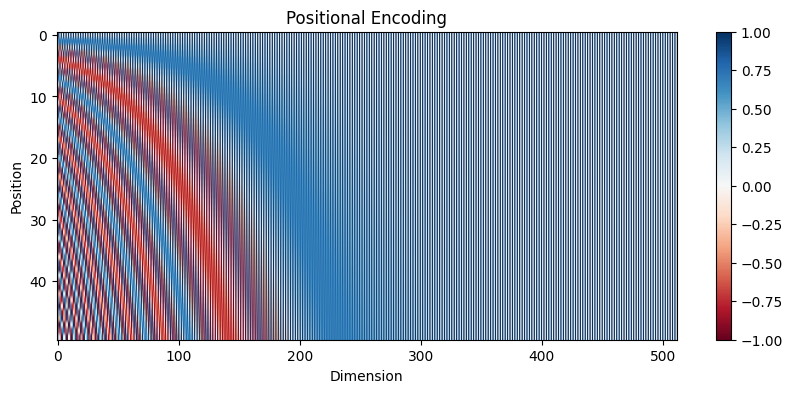

In [9]:
d_model = 512
max_len = 100

pe_layer = PositionalEncoding(d_model, max_len)

# 더미 입력
x = torch.zeros(2, 10, d_model)  
out = pe_layer(x)

print("input shape: ", x.shape)
print("output shape:", out.shape)

# 시각화 

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.imshow(pe_layer.pe[0, :50, :].numpy(), cmap='RdBu', aspect='auto')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding')
plt.colorbar()
plt.show()

### 인코더 레이어 

지금까지 만든 부품들을 조립하는 단계가 됨 
추가되는건 잔차연결, 레이어 정규화

1. 잔차 연결 f= f(x) + x 
변환된 값에 원본정보를 더해주는 것, 기울기 소실을 막고 정보소실도 같이 막아준다. 

2. 레이어 정규화 배치정규화와는 다르다. 
한 토큰의 벡터를 스케일링한다. 학습 중에 값이 폭주하는 걸 막아 다음 레이어가 안정적으로 받게 함.
토큰끼리 안 섞고, 각 토큰 안에서만 스케일링.

>> 벡터 안의 숫자들을 비슷한 범위로 다시 조정하는 일, 소프트맥스와 다른 점은 합 제약이 없고 음수/양수가 자유롭다는 점 그리고 스케일링한 후에도 학습 가능한 파라미터로 다시 조정 가능 


```
Input
  ↓
┌─────────────────────┐
│ Multi-Head Attention │ ──┐
└─────────────────────┘   │  잔차 연결
  ↓                        │
+──── Add ←────────────────┘
  ↓
LayerNorm
  ↓
┌─────────────────────┐
│ Position-wise FFN   │ ──┐
└─────────────────────┘   │  잔차 연결
  ↓                        │
+──── Add ←────────────────┘
  ↓
LayerNorm
  ↓
Output

```

In [10]:
import torch.nn as nn

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):

        attn_out, _ = self.self_attn(x, x, x, mask)  
        x = self.norm1(x + self.dropout1(attn_out))   
        

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))    
        
        return x

### 인코더 

1. 토큰을 임베딩으로 변환>> 보캡 ID를 백터로
2. 위치정보를 추가 >> 임베딩 +PE 
3. 인코더 레이어를 N번 통과 

임베딩 

보캡 사이즈 x 임베딩 차원 크기의 테이블을 학습 가능한 파라미터로 가지고 ID가 들어오면 그 행을 꺼내줌
학습 하면서 비슷한 의미는 비슷한 벡터가 되도록 조정해줌 

임베딩 스케일링>> 임베딩 값에도 √d_model을 곱해줌 
이 당시 논문에서는 이걸 썼다고ㅗ 나옴 아마 임베딩이 너무 작은 값일 때 그 값을 살려주기 위해서인것 같음 

임베딩 차원 = 모델의 표준차원 같음 
임베딩에서 차원이 맞아야 인코딩에서의 잔차처리도 수월할 테니까.... 




In [11]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=5000, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
    
    def forward(self, x, mask=None):
        
        x = self.embedding(x) * math.sqrt(self.d_model)
        
        x = self.pe(x)
        x = self.dropout(x)
        
        for layer in self.layers:
            x = layer(x, mask)
        
        return x

### 디코더 레이어 
```
Input (디코더 입력)
  ↓
┌─────────────────────────┐
│ Masked Self-Attention   │  ── 디코더 입력끼리. causal mask 적용
└─────────────────────────┘
  ↓ + 잔차 + LayerNorm
  ↓
┌─────────────────────────┐
│ Cross-Attention         │  ── Q는 디코더, K/V는 인코더 출력
└─────────────────────────┘
  ↓ + 잔차 + LayerNorm
  ↓
┌─────────────────────────┐
│ Position-wise FFN       │
└─────────────────────────┘
  ↓ + 잔차 + LayerNorm
  ↓
Output
```

인코더와는 구조가 다르다. 
트랜스포머의 원래 용도는 번역이었고 인코더는 영어문장을 인코딩한 표현으로 바꿔주는 역할을 했었음 
디코더는 그 표현을 받아 한국어 토큰을 생성하는 역할을 하고 말이다. 

결국 디코더는 자기회귀적은  구조를 가지고 있음 
자신이 만든 토큰에서 계속하여 다음 토큰을 예측하게 되는 것임 
때문에 디코더에게는 두가지 제약이 생긴다. 

하나는 미래를 보면 안된다는 것 이것이 마스크 셀프 어텐션 
캐주얼 마스크라는 기법으로 각 토큰은 자기 이전의 토큰들만 봀 수 있고 그게 아니라면 -inf 무한대의  값을 주어서 소프트맥스 시 값이  0이 되게 만든다. 

또 하나는 인코더 정보도 봐야 한다는 것이다. 
때문에 크로스 어텐션을 만들어서 디코더의 한국어 토큰은 Q가 되고 인코더의 영어 표현은 KV가 되는 구조를 만들어 디코더 내에 두개의 어텐션을 만들어 하나로 합친다. 최초의 한글 문장은 <sos> 같은 특수 태그로 시작함 


### 디코더 & 트랜스포머 전체 

디코더 레잉어를 쌓고 순전파에서 인코더 레이어의 값을 받는게 차이점임 
init에서 부품을 만들고 forward에서 순서대로 흘러가게 함 
그리고 집중력이 떨어져서 바로 트랜스포머 전체도 같이 돌리기로 했음... 


In [12]:
import torch
import torch.nn as nn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        #멀티헤드 어텐션 두개는 같은 클래스지만 별개 인스턴스 각자 자기만의 어텐션가중치를 학습함 
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    
    def forward(self, x, encoder_output, self_mask=None, cross_mask=None):
        #마스크 셀프 어텐션 
        attn_out, _ = self.self_attn(x, x, x, self_mask)
        x = self.norm1(x + self.dropout1(attn_out))
        # 크로스 어텐션
        cross_out, _ = self.cross_attn(x, encoder_output, encoder_output, cross_mask)
        x = self.norm2(x + self.dropout2(cross_out))
        #FFN
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))
        
        return x

In [13]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=5000, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
    
    def forward(self, x, encoder_output, self_mask=None, cross_mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pe(x)
        x = self.dropout(x)
        # 인코더 아웃풋은 모든 디코더 레이어로 ㅗ들어간다
        
        for layer in self.layers:
            x = layer(x, encoder_output, self_mask, cross_mask)
        
        return x

In [14]:
class Transformer(nn.Module):
    #보캡이 2개, 이건 영어사전크기와 한국어 사전크기가 다를수 있어서 다른 토크나이저 다른 보캡을 썼음 
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_heads=8, 
                 d_ff=2048, num_layers=6, max_len=5000, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout)
        
    #디코더 출력 > 보ㅗ캡 확률 
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)
    # 마스크가 두개임 역시 영어 문장과 한국어 두개 
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        encoder_output = self.encoder(src, src_mask)
        #디코더 안에서 셀프 어텐션용 마스크, 크로스 어텐션용 마스크 두개가 쓰이는데 역할이 다름
        decoder_output = self.decoder(tgt, encoder_output, tgt_mask, src_mask)
        logits = self.output_projection(decoder_output)
        return logits

In [15]:
src_vocab_size = 1000
tgt_vocab_size = 1000

model = Transformer(src_vocab_size, tgt_vocab_size, d_model=512, num_heads=8, 
                    d_ff=2048, num_layers=6)

src = torch.randint(0, src_vocab_size, (2, 10))  
tgt = torch.randint(0, tgt_vocab_size, (2, 8))   


tgt_mask = torch.tril(torch.ones(8, 8))

logits = model(src, tgt, src_mask=None, tgt_mask=tgt_mask)

print("src shape:    ", src.shape)        
print("tgt shape:    ", tgt.shape)        
print("logits shape: ", logits.shape)     

src shape:     torch.Size([2, 10])
tgt shape:     torch.Size([2, 8])
logits shape:  torch.Size([2, 8, 1000])


### 전처리 및 데이터 로딩 

트랜스포머를 구현하기 전 데이터 학습을 위해서 RNN에서 쓴 데이터셋을 그대로 쓰기로 했다. 
korean-english-park.train
korean-english-park.train
이며 전처리 방식은 이전과 유사하게 갈 생각이었다. 
우선 가장 처음으로 평행 코퍼스 작업을 위해 기본적인 길이 차이를 봐야했다. 이 데이터는 깨끗하지 않기 때문에 예를 들어 28번째 줄의 어휘 : 와 함께 전혀 맞지 않는 데이터가 정렬되어 있는 경우가 있었다. 

또한 중복제거또한 중요했다. 학습 데이터에서 흔한 문장이 많이 나왔는데 작은 데이터셋에 이렇게 많은 비율이 섞인 데이터는 과적합을 유발할 수 있었기 때문이다. 

3번째로 범위로 필터를 잡았는데 영어 한국어의 길이 비율은 보통 2~3배정도 되기 때문에 이것을 필터로 잡았다. 
4번쨰는 정규식을 과하게 쓰지 않고 BPE의 기능에 기대는 것이 특징이었다. 보통 내가 지금까지 작업 할 때는 여러 특수문자나 패턴을 정규식으로 잡아 필터링 했었는데 이번에는 BPE를 쓰기 때문에 과하게 하지는 않았다. 토크나이저가 해결 못하는 것만 전처리에서 잡는다. 


In [16]:
import os, re

#한경설정 

KO_PATH = "korean-english-park.train.ko"   
EN_PATH = "korean-english-park.train.en"
OUT_DIR = "data_clean"


os.makedirs(OUT_DIR, exist_ok=True)

with open(KO_PATH, encoding="utf-8") as f:
    ko_lines = [l.rstrip("\n") for l in f]
with open(EN_PATH, encoding="utf-8") as f:
    en_lines = [l.rstrip("\n") for l in f]
assert len(ko_lines) == len(en_lines)

def normalize(s):
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s


# 필터 기준
RATIO_MIN, RATIO_MAX = 1/3, 3.0
LEN_MIN, LEN_MAX = 5, 250    # 글자 수

clean_ko, clean_en = [], []
seen = set()
stats = {"empty":0, "nokr":0, "len":0, "ratio":0, "dup":0, "kept":0}

def has_korean(s, min_ratio=0.3):
    korean_chars = sum(1 for c in s if '가' <= c <= '힣')
    return korean_chars / max(len(s), 1) >= min_ratio

for ko, en in zip(ko_lines, en_lines):
    ko, en = normalize(ko), normalize(en)
    if not ko or not en:
        stats["empty"] += 1; continue
    if not has_korean(ko):
        stats["nokr"] += 1; continue
    if not (LEN_MIN <= len(ko) <= LEN_MAX and LEN_MIN <= len(en) <= LEN_MAX):
        stats["len"] += 1; continue
    ko_n = len(ko.replace(" ", ""))
    en_n = len(en.replace(" ", ""))
    r = en_n / ko_n
    if not (RATIO_MIN <= r <= RATIO_MAX):
        stats["ratio"] += 1; continue
    key = (ko, en)
    if key in seen:
        stats["dup"] += 1; continue
    seen.add(key)
    clean_ko.append(ko); clean_en.append(en)
    stats["kept"] += 1

print(f"원본: {len(ko_lines):,} pairs")
for k, v in stats.items():
    print(f"  {k:>6}: {v:>6,}")
print(f"보존율: {stats['kept']/len(ko_lines)*100:.1f}%")



# BPE 학습용으로 저장
KO_CLEAN = os.path.join(OUT_DIR, "train.ko")
EN_CLEAN = os.path.join(OUT_DIR, "train.en")
with open(KO_CLEAN, "w", encoding="utf-8") as f:
    f.write("\n".join(clean_ko))
with open(EN_CLEAN, "w", encoding="utf-8") as f:
    f.write("\n".join(clean_en))

원본: 94,123 pairs
   empty:      0
    nokr:  2,875
     len:  3,369
   ratio: 10,612
     dup: 13,605
    kept: 63,662
보존율: 67.6%


stats, dict로 카운트하는 패턴이다. 
범위에서 많이 잘리거나 길이나 듀플이 너무 많지 않는지 확인하는 것 
현재 길이는 3.7%, 비율은 11퍼센트, 듀플은 14퍼센트가 나왔는데 생각보다 많아서 샘플을 직접 확인한다. 


In [17]:
import random
random.seed(42)
for i in random.sample(range(len(clean_ko)), 10):
    print(f"[{i}]")
    print(f"  KO: {clean_ko[i]}")
    print(f"  EN: {clean_en[i]}")
    print()

[41905]
  KO: 시랜든 나이도 로빈 아일랜드 박물관 임시 관장은 “현지 동물 보도 단체들과 합동으로 인도적 폐사 프로그램 시행 외 에는 대안이 없다”고 밝혔다.
  EN: Robben Island Museum interim chief executive Seeland Naidoo says there is no alternative but to implement a "humane culling program" in conjunction with local animal welfare groups.

[7296]
  KO: 이에따라 버락 오바마 상원의원은 대의원 확보 경쟁에서 라이벌인 힐러리 클린턴 상원의원에 앞서나갈 수 있게 됐다.
  EN: The move will leave front-runner Sen. Barack Obama's lead over rival Sen. Hillary Clinton intact.

[1639]
  KO: 멕시코 수감자들은 평균적으로 일당 45페소(4달러 50센트)의 최소 임금을 버는데 이는 국경지대에서 활동하는 자유 노동자들이 받는 임금의 절반에 해당한다.
  EN: On average, Mexican inmates earn the minimum wage of 45 pesos a day ($4.50), half what free workers along the border make.

[48598]
  KO: (여자 목소리)“ 취임식에 가려는 사람들은 화려한 드레스나 고급 정장을 장만하는 것 말고도 보톡스 시술까지 받고 있습니다.
  EN: (female voice)“ Along with the dressy dresses and chic suits, people are breaking out the Botox to go to the Inauguration.

[18024]
  KO: 그는 선데이텔레그래프 기고문에서 영국에서 현재 8000여명이 장기기증을 기다리고 있지만 매년 장기이식 시술은 단 3000여건만 이뤄지고 있다

### BPE 
BPE는 빈도 압축 알고리즘이다. 
가장 자주같이 나오는 토큰 쌍을 하나로 합치는걸 보캡 사이즈에 도달할 때 까지 반복한다. 
예를 들어 영어에서  ing같은 부분이 한 ㅌ큰으로 만들어 지는 것임. 
한국어에서라면 아마 습니다. 다나까 같은 것들이 하나로 합쳐질 경우가 큼 

또한 띄워쓰기 과노련해서 작업이 편하다. ▁같은 유니코드 문자를 사용해서 띄어쓰기를 통째로 처리함 이 때 공백이 토큰 안에 박히니까 다시 문장으로 합칠 때 띄어쓰기가 자동으로 복원되는것 같음. 

보캡 사이즈 8천 
이전 RNN에서는 1.6k였지만 이번엔 그 절반의 사이즈였다. 데이터셋 대비 평균 토큰 빈도가 너무 낮아질수 있기 때문에 이번엔 8천지 적절한 보캡사이즈라고 생각했음 RNN과는 다르다는 점도 한몫하는것 같긴 함 

In [18]:
import sentencepiece as spm

VOCAB_SIZE = 8000
SP_DIR = "sp_models"
os.makedirs(SP_DIR, exist_ok=True)

# 영어 토크나이저 학습
spm.SentencePieceTrainer.train(
    input=EN_CLEAN,
    model_prefix=f"{SP_DIR}/spm_en",
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    character_coverage=1.0,        
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece="<pad>", unk_piece="<unk>",
    bos_piece="<bos>", eos_piece="<eos>",
)

# 한국어 토크나이저 학습
spm.SentencePieceTrainer.train(
    input=KO_CLEAN,
    model_prefix=f"{SP_DIR}/spm_ko",
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    character_coverage=0.9995,     
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece="<pad>", unk_piece="<unk>",
    bos_piece="<bos>", eos_piece="<eos>",
)

# 로딩
sp_en = spm.SentencePieceProcessor(model_file=f"{SP_DIR}/spm_en.model")
sp_ko = spm.SentencePieceProcessor(model_file=f"{SP_DIR}/spm_ko.model")

print(f"영어 vocab: {sp_en.vocab_size()}")
print(f"한국어 vocab: {sp_ko.vocab_size()}")

# 동작 확인
test_en = "The quick brown fox jumps over the lazy dog."
test_ko = "오늘 아침에 커피를 마시면서 책을 읽었다."

print("\n[EN]", test_en)
print("토큰:", sp_en.encode(test_en, out_type=str))
print("ID:  ", sp_en.encode(test_en))

print("\n[KO]", test_ko)
print("토큰:", sp_ko.encode(test_ko, out_type=str))
print("ID:  ", sp_ko.encode(test_ko))

영어 vocab: 8000
한국어 vocab: 8000

[EN] The quick brown fox jumps over the lazy dog.
토큰: ['▁The', '▁quick', '▁b', 'rown', '▁f', 'ox', '▁jump', 's', '▁over', '▁the', '▁l', 'az', 'y', '▁dog', '.']
ID:   [77, 2497, 26, 1823, 23, 3353, 3360, 7874, 306, 9, 54, 632, 7885, 2665, 7888]

[KO] 오늘 아침에 커피를 마시면서 책을 읽었다.
토큰: ['▁오늘', '▁아침', '에', '▁커피', '를', '▁마시', '면서', '▁책을', '▁읽', '었다', '.']
ID:   [766, 1406, 6683, 4299, 6699, 5189, 272, 6209, 4765, 76, 6684]


### 길이 분포 

PAD, BOS, EOS 같은 특수 태그들을 ID리스트로 바꿔준다. 
sp_ko.encode(s)가 토크나이저가 하는 일이고 문장을 토큰 ID리스트로 바꿔주는 일을 한다. 
이 ID하나하나가 보캡 테이블의 인덱스가 되고 모델 안 임베딩 레이어 ( 8000, 512) 에서 이 ID를 받아 8000x512테이블에서 해당 행을 가져온다. 
encode는 학습때 만든 BPE규칙을 그대로 적용한다. 

그 뒤로 길이 분포를 확인해서 시각화 해본다. 
시각화를 하니 그래프에 이상치가 많은 걸 확인할수 있었다. 
우선 왼쪽의 그래프는 규칙적으로 그래프가 위로 뛰었고 오른쪽 그래프 역시 몇군데에서 이상치가 발생한것 같았다. 





[EN (src)]
  평균: 29.7
  중앙값: 28
  p 50: 28
  p 75: 37
  p 90: 46
  p 95: 52
  p 99: 66
  p100: 122
  최대: 122

[KO (tgt)]
  평균: 31.7
  중앙값: 31
  p 50: 31
  p 75: 40
  p 90: 49
  p 95: 54
  p 99: 63
  p100: 90
  최대: 90


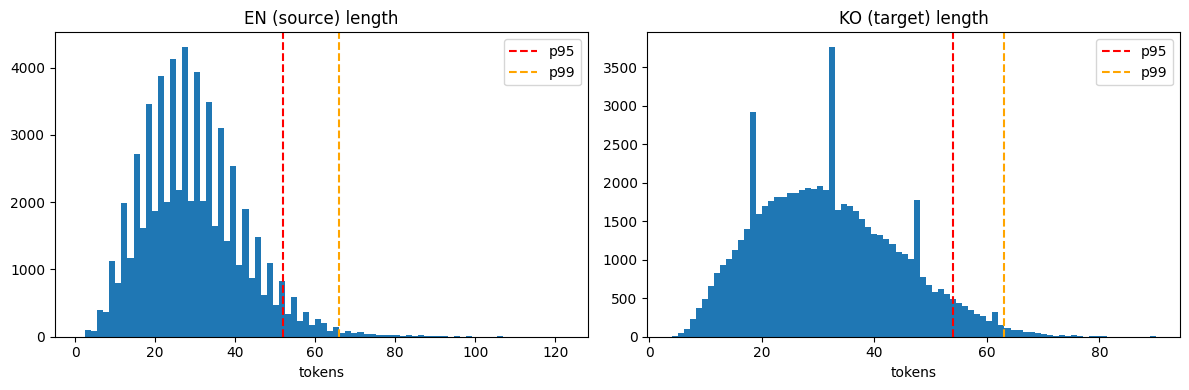

In [19]:
import numpy as np
import matplotlib.pyplot as plt

PAD_ID = sp_ko.pad_id()   
BOS_ID = sp_en.bos_id()   
EOS_ID = sp_en.eos_id()   

# 인코딩
# 인코더 입력(영어): 그대로 토큰화만
# 디코더 입력(한국어): <bos> + 토큰 + <eos>
src_ids = [sp_ko.encode(s) for s in clean_ko]
tgt_ids = [[BOS_ID] + sp_en.encode(s) + [EOS_ID] for s in clean_en]

# 길이 분포
src_lens = np.array([len(x) for x in src_ids])
tgt_lens = np.array([len(x) for x in tgt_ids])

def show_stats(name, lens):
    print(f"\n[{name}]")
    print(f"  평균: {lens.mean():.1f}")
    print(f"  중앙값: {np.median(lens):.0f}")
    for p in [50, 75, 90, 95, 99, 100]:
        print(f"  p{p:>3}: {np.percentile(lens, p):.0f}")
    print(f"  최대: {lens.max()}")

show_stats("EN (src)", src_lens)
show_stats("KO (tgt)", tgt_lens)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(src_lens, bins=80)
axes[0].set_title("EN (source) length")
axes[0].set_xlabel("tokens")
axes[0].axvline(np.percentile(src_lens, 95), color='r', linestyle='--', label='p95')
axes[0].axvline(np.percentile(src_lens, 99), color='orange', linestyle='--', label='p99')
axes[0].legend()

axes[1].hist(tgt_lens, bins=80)
axes[1].set_title("KO (target) length")
axes[1].set_xlabel("tokens")
axes[1].axvline(np.percentile(tgt_lens, 95), color='r', linestyle='--', label='p95')
axes[1].axvline(np.percentile(tgt_lens, 99), color='orange', linestyle='--', label='p99')
axes[1].legend()

plt.tight_layout()
plt.show()

### 그래프 시각화 다시 

bins = 80으로 놓으니 막대가 짝/홀로 삐죽삐죽하게 솟았음 
bin 폭이 1.1으로 정수 경계에 안 맞아서 2개나 1개씩 맞지 않게 들어갔음 
그래서 이 그래프 가시를 바꿔서 다시 확인을 해본게 아래 그래프였음 

- KO: p95=52, p99=65, max 124
- EN: p95=54, p99=63, max 90
- max_len=64 결정 — 99% 커버, 메모리 효율 (2의 거듭제곱)
- 64 넘는 페어 약 1%는 컷에서 제외

긴 한국어 페어 일부는 한국어 쪽이 잘려있음 

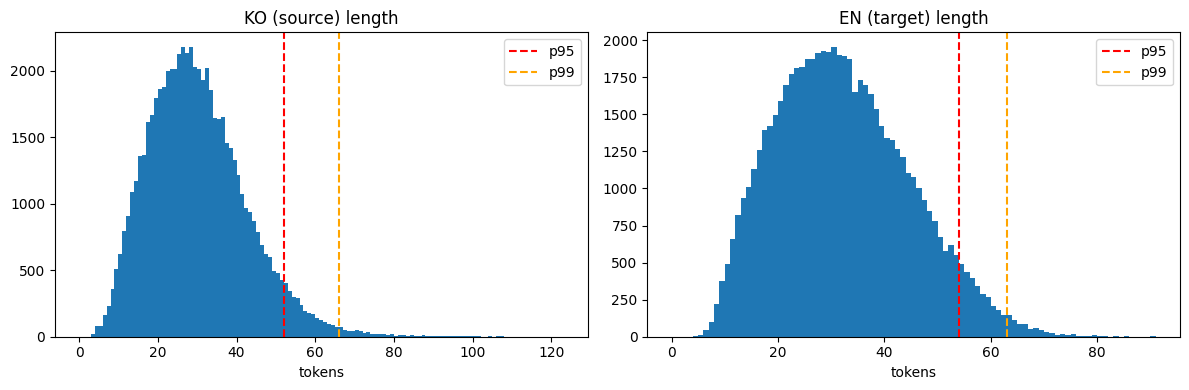

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 한국어 (src)
src_max = src_lens.max()
axes[0].hist(src_lens, bins=range(0, src_max + 2))
axes[0].set_title("KO (source) length")
axes[0].set_xlabel("tokens")
axes[0].axvline(np.percentile(src_lens, 95), color='r', linestyle='--', label='p95')
axes[0].axvline(np.percentile(src_lens, 99), color='orange', linestyle='--', label='p99')
axes[0].legend()

# 영어 (tgt)
tgt_max = tgt_lens.max()
axes[1].hist(tgt_lens, bins=range(0, tgt_max + 2))
axes[1].set_title("EN (target) length")
axes[1].set_xlabel("tokens")
axes[1].axvline(np.percentile(tgt_lens, 95), color='r', linestyle='--', label='p95')
axes[1].axvline(np.percentile(tgt_lens, 99), color='orange', linestyle='--', label='p99')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
import random
random.seed(0)

for target_len in [17, 30, 47]:
    matching = [i for i, ids in enumerate(src_ids) if len(ids) == target_len]
    print(f"\n=== EN 길이 {target_len} 페어 (총 {len(matching)}개, 랜덤 5개) ===")
    for i in random.sample(matching, min(5, len(matching))):
        print(f"  EN: {clean_en[i]}")
        print(f"  KO: {clean_ko[i][:60]}")
        print()


=== EN 길이 17 페어 (총 1610개, 랜덤 5개) ===
  EN: Why not promote the culture we do have?"
  KO: 우리 도시가 갖고 있는 문화를 활성화 해야 맞는 것 이다.”

  EN: “ GM actually plans to cut 2,600 dealers ?
  KO: “ 실제 GM의 목표는 2,600개 딜러망을 해지하는 것입니다.

  EN: And doctors in India say they have performed appendectomies through the mouth.
  KO: 그리고 인도에 있는 의사들은 그들이 입을 통해 맹장 수술을 집도했다고 밝혔다.

  EN: They also accused Washington of heightening tensions on the Korean Peninsula by refusing to directly deal with North Korea.
  KO: 그들은 미국이 대북한 직접 협상을 거부함으로써 한반도에서의 긴장을 고조시키고 있다고 비난했다.

  EN: But a United News of Bangladesh report put the death toll at at least 1,100.
  KO: 그러나 방글라데시의 일부 언론은 ‘사드르’로 최소 1100명이 숨졌다고 보도했다.


=== EN 길이 30 페어 (총 2009개, 랜덤 5개) ===
  EN: The Korea Times reports a second generation Korean American was arrested here after evading an FBI search for nearly nine years on charges of killing a retired policeman in the United States.
  KO: 코리아 타임즈지는 미국에서 은퇴한 경관을 살해하고 거의 9년간 FBI의 수색을 피해 온 2세대 한국계 미국인

  EN: But House 

In [21]:
from sklearn.model_selection import train_test_split

MAX_LEN = 64

# 영어, 한국어 둘 다 MAX_LEN 이하인 페어만 유지
# 한국어는 <bos>, <eos> 포함 길이라 사실상 본문 62토큰까지
filtered = [(s, t) for s, t in zip(src_ids, tgt_ids) 
            if len(s) <= MAX_LEN and len(t) <= MAX_LEN]

print(f"길이 컷 전: {len(src_ids):,}")
print(f"길이 컷 후: {len(filtered):,}")
print(f"보존율: {len(filtered)/len(src_ids)*100:.1f}%")

src_filtered = [p[0] for p in filtered]
tgt_filtered = [p[1] for p in filtered]

# train/valid split
src_train, src_valid, tgt_train, tgt_valid = train_test_split(
    src_filtered, tgt_filtered, test_size=0.05, random_state=42
)

print(f"\ntrain: {len(src_train):,}")
print(f"valid: {len(src_valid):,}")

길이 컷 전: 63,662
길이 컷 후: 62,587
보존율: 98.3%

train: 59,457
valid: 3,130


### 데이터셋 

일단은 데이터 학습을 시켜 빠르게 모델 결과를 확인하는게 좋겠다 싶어 데이터셋부터 구성하기로 한다. 
데이터셋은 __len__(self) 전체 샘플 개수 __getitem__(self, idx) 인덱스를 받아 샘플을 반환하는 구조로 되어있었다. 
파이토치에서는 이 두개가 완성되면 나머지는 거의 알아서 해주는것 같음. 파이토치를 쓰는 이유가 있구나 싶었다. dtype=torch.long 은 중요하다는것 같았다. 왜냐면 임베딩 레이어는 롱 타입의 인덱스만 받기 때문이라고 한다. 

def collate_fn(batch) 
이 부분에서는 배치구성으로 되어있다. 
데이터 로더가 배치 사이즈만큼 샘플을 모아서 리스트로 만들어 넘겨주는 방식이다. 

1. 데이터로더가 데이터셋에게 인덱스 64개를 요청 셔플=참 이면 무작위 
2. 데이터셋.gewtitem 64번 호출 > 텐서 64개를 페어받음 
3. 이걸 리스트로 묶어 collate _ fn에 넘김 
4. 이것을 패딩해서 B,L모양 텐서 두개 반환 
5. 학습 루프가 for src, tgt in loader:로 받음
매 배치마다 반복된다고 함 

꼭 필요하다 싶은 옵션들도 있었다. 

num_workers > 데이터 로딩을 별도 프로세스로ㅗ 하는것, CPU에서 데이터 준비하는 동안 GPU가 학습 병목 줄이기 
pin_memory = True 메모리에 페이지 고정해서 GPU 전송속도 up, cuda쓸때만 가능 
drop_last=True 배치 사이즈가 많을 때 일정 단위로 나누다 보면 작은 배치가 통계를 망치는 일이 있다는것 같음 그래서 아예 버려주는 듯함 

In [22]:
import torch
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_ids, tgt_ids):
        self.src = src_ids
        self.tgt = tgt_ids
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return torch.tensor(self.src[idx], dtype=torch.long), \
               torch.tensor(self.tgt[idx], dtype=torch.long)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = torch.nn.utils.rnn.pad_sequence(
        src_batch, batch_first=True, padding_value=PAD_ID
    )
    tgt_padded = torch.nn.utils.rnn.pad_sequence(
        tgt_batch, batch_first=True, padding_value=PAD_ID
    )
    return src_padded, tgt_padded

BATCH_SIZE = 64

train_ds = TranslationDataset(src_train, tgt_train)
valid_ds = TranslationDataset(src_valid, tgt_valid)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=collate_fn)

# 한 배치 확인
src_sample, tgt_sample = next(iter(train_loader))
print(f"src batch: {src_sample.shape}")  # (B, L_src)
print(f"tgt batch: {tgt_sample.shape}")  # (B, L_tgt)
print(f"\nsrc[0]: {src_sample[0][:20].tolist()}")
print(f"tgt[0]: {tgt_sample[0][:20].tolist()}")

src batch: torch.Size([64, 52])
tgt batch: torch.Size([64, 63])

src[0]: [205, 288, 12, 6954, 6707, 64, 6829, 6716, 532, 6774, 3301, 6683, 3774, 131, 912, 136, 7168, 6872, 61, 7168]
tgt[0]: [2, 456, 910, 162, 5810, 124, 634, 21, 93, 80, 94, 104, 6829, 1032, 32, 6, 3666, 93, 2848, 1887]


### 마스크 작업 

1번은 인코더에 붙는 마스킹이다. 패딩을 가리려고 하는건데 배치 길이 다른 문장들 뒤에는 <pad>가 채워질수 있다 어텐션은 모든 토큰을 다 보기 때문에 패딩까지 보는 문제가 생김 마스크로 패딩 자리를 -inf로 만들면 가중치가 0이 됨 
2번은 셀프 어텐션에 붙는 마스킹 이건 대각선 위쪽의 미래정보를 -inf로 만들어 미래정보를 보지 못하게 만든다. 
tgt_mask는 캐주얼 + 패딩 둘 다 가림

In [23]:
def make_src_mask(src, pad_id=PAD_ID):
    return (src != pad_id).unsqueeze(1).unsqueeze(2)

def make_tgt_mask(tgt, pad_id=PAD_ID):
    B, L = tgt.shape
    pad_mask = (tgt != pad_id).unsqueeze(1).unsqueeze(2)         # (B, 1, 1, L)
    causal = torch.tril(torch.ones(L, L, device=tgt.device)).bool()  # (L, L)
    return pad_mask & causal                                      # 브로드캐스트

# 테스트
src_sample, tgt_sample = next(iter(train_loader))
src_mask = make_src_mask(src_sample)
tgt_mask = make_tgt_mask(tgt_sample)
print(f"src: {src_sample.shape}, src_mask: {src_mask.shape}")
print(f"tgt: {tgt_sample.shape}, tgt_mask: {tgt_mask.shape}")

src: torch.Size([64, 58]), src_mask: torch.Size([64, 1, 1, 58])
tgt: torch.Size([64, 63]), tgt_mask: torch.Size([64, 1, 63, 63])


### 하이퍼파라미터 설정 

cuda로 기본 gpu로 돌리고 아니면 cpu로 돌린다. 

src_vocab_size=SRC_VOCAB
인코더 임베딩 테이블 크기는 8천행이다. 
차원으로 따지면 (8000,512)
tgt_vocab_size=TGT_VOCAB
디코더 임베딩 테이블 크기다. 영어토큰용이고 차원은 같아야함 
d_model = 512 
모델 전체의 통일된 벡터 차원, 한 토큰을 표현하는 벡터의 크기이기도 함 
num_heads=8
멀티헤드 어텐션의 헤드 수, d_model=512를 8개로 나눠서 각 헤드가 64차원에서 어텐션 수행
헤드마다 다른 패턴 학습 
d_ff=2048
FFN 확장 차원 512>2048>512

num_layers = 6 
인코더 레이어 6개, 디코더 레이어 6개 
깊을수록 추상적인 표현, 어텐션 논문에서의 베이스 모델 설정 
max_len=128
위치 인코딩에서 미리 계산해두는 최대길이 

dropout=0.1
과적합 방지를 위해 학습중 뉴런 10%를 무작위로 끔 
.to(device)
모도ㅔㄹ파라미터 전부 GPU로 '
안 옮기면 모델은 CPU 데이터는 GPU에 있어서 순전파시 에러 


In [24]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

SRC_VOCAB = sp_ko.vocab_size()
TGT_VOCAB = sp_en.vocab_size()

model = Transformer(
    src_vocab_size=SRC_VOCAB,
    tgt_vocab_size=TGT_VOCAB,
    d_model=512, num_heads=8, d_ff=2048,
    num_layers=6, max_len=128, dropout=0.1
).to(device)

# loss — PAD 무시, label smoothing
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

device: cuda
파라미터 수: 56,434,496


In [25]:
import sys
!{sys.executable} -m pip install tqdm



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from tqdm import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for src, tgt in tqdm(loader, desc="train"):
        src, tgt = src.to(device), tgt.to(device)
        
        # teacher forcing: 디코더 입력은 한 칸 앞, 정답은 한 칸 뒤
        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        
        src_mask = make_src_mask(src)
        tgt_mask = make_tgt_mask(tgt_in)
        
        logits = model(src, tgt_in, src_mask, tgt_mask)
        # logits: (B, L, V), tgt_out: (B, L) — flatten해서 CE에 넣음
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        src_mask = make_src_mask(src)
        tgt_mask = make_tgt_mask(tgt_in)
        logits = model(src, tgt_in, src_mask, tgt_mask)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

# 학습 실행
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    valid_loss = eval_epoch(model, valid_loader, criterion, device)
    print(f"[Epoch {epoch}] train: {train_loss:.4f} | valid: {valid_loss:.4f} | ppl: {torch.exp(torch.tensor(valid_loss)):.2f}")

train: 100%|██████████| 930/930 [03:30<00:00,  4.42it/s]


[Epoch 1] train: 6.5741 | valid: 6.0467 | ppl: 422.73


train: 100%|██████████| 930/930 [03:14<00:00,  4.78it/s]


[Epoch 2] train: 5.8524 | valid: 5.6131 | ppl: 274.00


train: 100%|██████████| 930/930 [03:12<00:00,  4.84it/s]


...

[Epoch 8] train: 4.5367 | valid: 4.7780 | ppl: 118.86


train: 100%|██████████| 930/930 [03:18<00:00,  4.68it/s]


[Epoch 9] train: 4.4083 | valid: 4.7293 | ppl: 113.22


train: 100%|██████████| 930/930 [03:24<00:00,  4.54it/s]


[Epoch 10] train: 4.2871 | valid: 4.7035 | ppl: 110.33


In [30]:
import torch

@torch.no_grad()
def translate(model, sentence, sp_src, sp_tgt, device, max_len=64):
    model.eval()
    
    src_ids = sp_src.encode(sentence)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = make_src_mask(src)
    encoder_output = model.encoder(src, src_mask)
    
    tgt = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    
    for _ in range(max_len):
        tgt_mask = make_tgt_mask(tgt)
        decoder_output = model.decoder(tgt, encoder_output, tgt_mask, src_mask)
        logits = model.output_projection(decoder_output)
        next_token = logits[:, -1, :].argmax(dim=-1)
        tgt = torch.cat([tgt, next_token.unsqueeze(1)], dim=1)
        if next_token.item() == EOS_ID:
            break
    
    out_ids = tgt[0, 1:].tolist()
    if out_ids and out_ids[-1] == EOS_ID:
        out_ids = out_ids[:-1]
    return sp_tgt.decode(out_ids)


test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

for s in test_sentences:
    pred = translate(model, s, sp_ko, sp_en, device)
    print(f"Input:  {s}")
    print(f"Output: {pred}")
    print()

Input:  오바마는 대통령이다.
Output: Obama is the president.

Input:  시민들은 도시 속에 산다.
Output: The city's city is the city's biggest city.

Input:  커피는 필요 없다.
Output: There are no immediate need.

Input:  일곱 명의 사망자가 발생했다.
Output: The dead were killed in the blast.



### 회고 

트랜스포머를 직접 논문을 보면서 구현하면서 데이터 학습을 시켜 결과를 확인해봤음 
솔직히 좀 실망스러웠지만 임베딩 모델이나 토크나이저가 올바르지 않았을 지도 라는 생각이 들어서 개선점은 많이 존재한다고 생각함 
사실 이전 코드 줄에서 score을 오타를 내서 모든 모델의 출력이 ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,, 
처럼 출력이 되서 조금 많이 멘탈이 흔들렸었음 

디버깅  과정이 너무 지저분하고 길어서 남기지는 않았지만 오류가 생기면 우선은 침착해야 한다는 생각이 들었음 
모델의 출력결과는 10 에폭을 토대로 출력한 값이기 때문에 20에폭정도를 돌린다면 더 좋은 결과가 나오지 않을까 하는 생각이 있음 
우선 이후에는 이전 RNN처럼 임베딩 모델에서의 학습이 제대로 되지 않아 각 토큰들이 제대로 차원에 분포되지 않아서 생기는 문제가 아니었을 까 하는 의심이 있어 각 토큰이 임베딩 차원에서 어떻게 분포되어있는지 밑의 코드를 통해 확인해보기로 했음 




### 임베딩 차원 분포도 시각화 

1번 시각화는 점들이 0,0 을 중심으로 거의 원형처럼 퍼져있다. 이건 한/영 둘다 생기는 문제인데 
내 생각에는 각 토큰이 제대로 임베딩좌표로 학습이 됬었다면 이런 분포를 보이지 않고 각 토큰간 군집을 이루거나 거리를 보이는 듯 어느정도는 의미있는 방향성이나 군집이 보였을 것이다. 하지만 이건 그런게 보이지 않았던 것 같았다. 
이건 아마 너무 작은 데이터셋이 제대로 학습을 만들지 못하게 했던게 아닐까. 

2번 같은 경우에는 학습을 하지 않은 임베딩과 학습한 임베딩 차원의 분포를 비교해서 시각화 한 것이다. 
의미있는 변화가 있었나??? 싶기는하지만 흔한 패턴에 대한 것은 금방 외우는 모습을 보여준것 같았다. 
어쩌면 RNN보다 좀 더 성능이 떨어지는 느낌을 받기도 했음 레이어층이 더 깊어져야 하는 걸까 아니면 RNN같은 작은 모델이 작은 데이터에서는 더 강점을 보이는 걸까 

C:\Users\akals\AppData\Local\Temp\ipykernel_18940\412671756.py:28: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_18940\412671756.py:28: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_18940\412671756.py:28: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_18940\412671756.py:28: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_18940\412671756.py:28: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\akals\AppData\Local\Temp\ipykernel_18940\412671756.py:28: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s

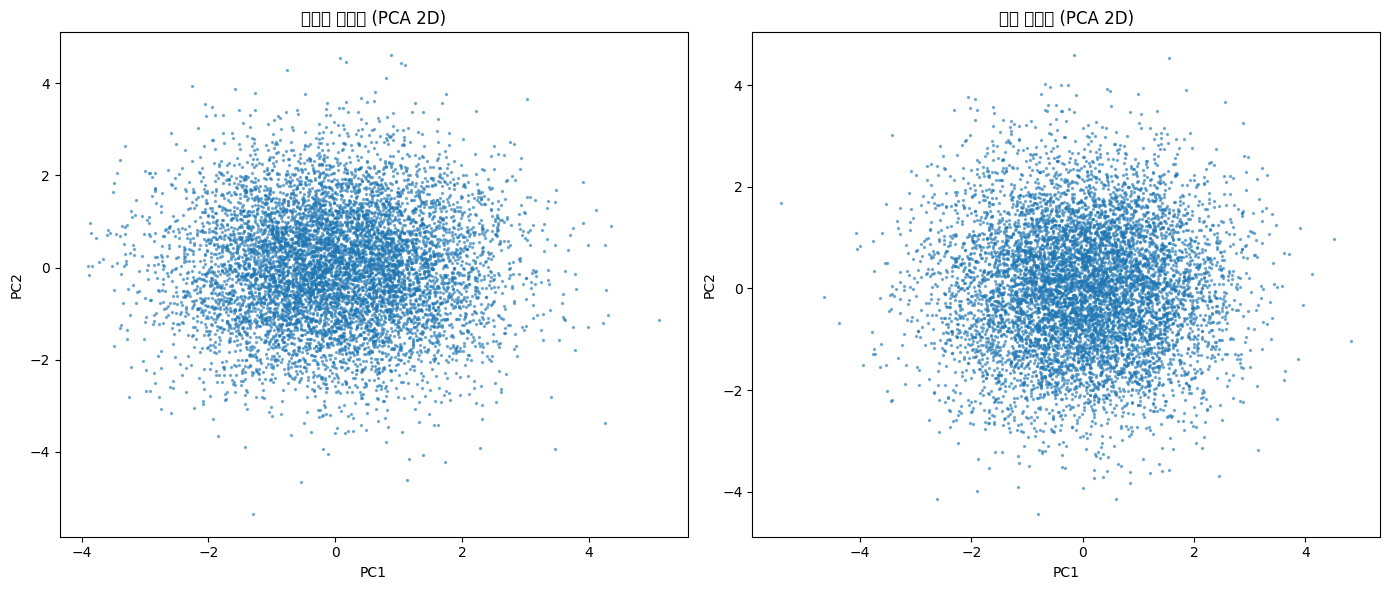

한국어 PC1, PC2 설명비율: [0.00304538 0.00301378]
영어 PC1, PC2 설명비율: [0.00303868 0.00302089]


In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 인코더 임베딩 (한국어)
ko_emb = model.encoder.embedding.weight.detach().cpu().numpy()  # (8000, 512)

# 디코더 임베딩 (영어)
en_emb = model.decoder.embedding.weight.detach().cpu().numpy()  # (8000, 512)

# PCA로 2D 투영
pca_ko = PCA(n_components=2).fit_transform(ko_emb)
pca_en = PCA(n_components=2).fit_transform(en_emb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(pca_ko[:, 0], pca_ko[:, 1], s=2, alpha=0.5)
axes[0].set_title("한국어 임베딩 (PCA 2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(pca_en[:, 0], pca_en[:, 1], s=2, alpha=0.5)
axes[1].set_title("영어 임베딩 (PCA 2D)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

print(f"한국어 PC1, PC2 설명비율: {PCA(n_components=2).fit(ko_emb).explained_variance_ratio_}")
print(f"영어 PC1, PC2 설명비율: {PCA(n_components=2).fit(en_emb).explained_variance_ratio_}")

랜덤 초기화 norm 평균: 22.62
우리 모델 한국어 norm 평균: 22.61
차이: 0.01


C:\Users\akals\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\akals\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\akals\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\akals\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\akals\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 510

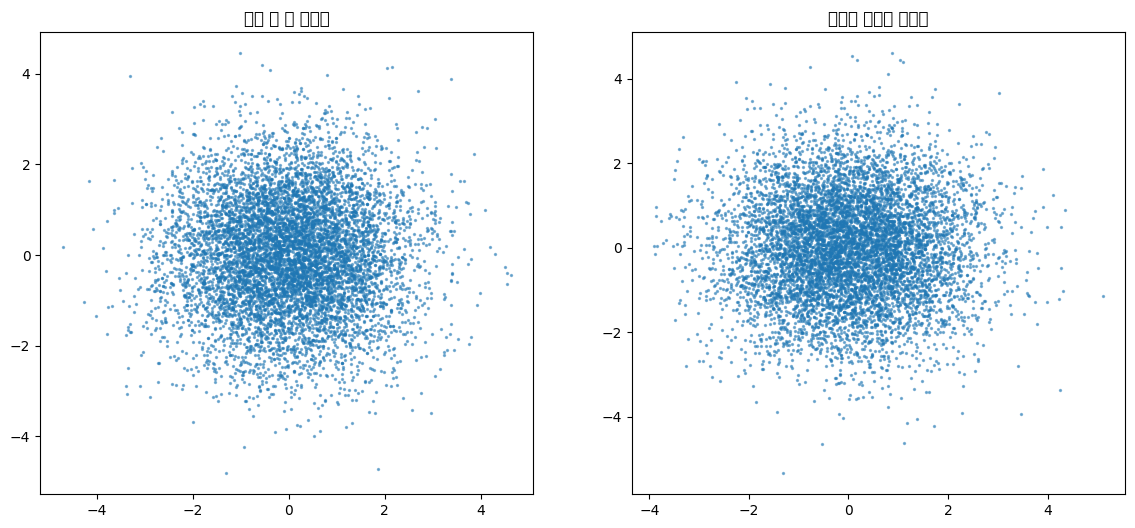

In [33]:
import torch.nn as nn

# 새 임베딩 (학습 안 한 거)
random_emb = nn.Embedding(8000, 512)
random_weights = random_emb.weight.detach().cpu().numpy()
pca_random = PCA(n_components=2).fit_transform(random_weights)

# norm
random_norms = np.linalg.norm(random_weights, axis=1)
print(f"랜덤 초기화 norm 평균: {random_norms.mean():.2f}")
print(f"우리 모델 한국어 norm 평균: {ko_norms.mean():.2f}")
print(f"차이: {abs(random_norms.mean() - ko_norms.mean()):.2f}")

# 시각화 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(pca_random[:, 0], pca_random[:, 1], s=2, alpha=0.5)
axes[0].set_title("학습 안 한 임베딩")
axes[1].scatter(pca_ko[:, 0], pca_ko[:, 1], s=2, alpha=0.5)
axes[1].set_title("학습한 한국어 임베딩")
plt.show()